In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **DBSCAN - Density-based Spatial Clustering of Applications with Noise**

**Алгоритм для кластеризации данных и поиска выбросов (outliers)**

Использует плотность точек как основной фактор для обхединения точек в калстерв

Может проводить сегментацию данных, когда другие методы не справляются

Два кластера в виде "луны" ("moon")

DBSCAN выполняет итерации по точкам, используя 2 гиперпараметра (эпсилон и минимальное кол-во точек) для назначения кластеров.

В отличие от K-means, использует плотность точек в качестве основной метрики

**Эпсилон**

Некое расстояние вокруг каждой точек, эпсилон-корестность

**Минимальное количество точек**

Сколько минимально точек должно быть в этой эпссилон-окрестности

**Типы точек в алгоритме DBSCAN**

- **Core** - точка, имеющая минимальное количество точек в эпсилон-окрестности (включая саму точку)
- **Border** - находится в эпсилон-окрестности core точки, но сама не имеет минимальное кол-во точек в своей эпсилон-окрестности
- **Outlier** - до этой точки нельзя "добраться" в процессе итерации по точкам, т.е. слишком далеко от других точек, "шум"

**Шаги алгоритма DBSCAN**

1) берем случайную точку, не принадлежащую ни к одному кластеру
2) определяем тип точки (core/border/outlier)
3) Если найдена точка core, то все точки в ее эпсилон-окрестности помещаются в тот же класс, что и эта точка core
4) Повторяем для всех точек - все точки будут либо в кластерах, либо выбросами (outliers)

## **DBCSAN vs. K-Means на одних и тех же данных**

In [3]:
blobs = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\cluster_blobs.csv")

In [4]:
blobs.shape

(1500, 2)

In [5]:
blobs.head()

,X1,X2
0,4.645333,6.822294
1,4.784032,6.422883
2,-5.851786,5.774331
3,-7.459592,6.456415
4,4.918911,6.961479


<Axes: xlabel='X1', ylabel='X2'>

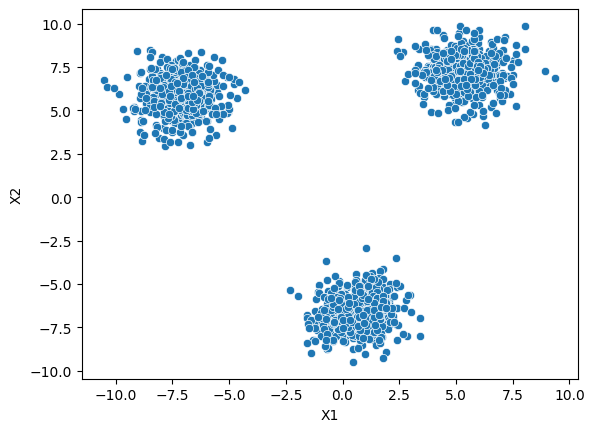

In [7]:
sns.scatterplot(data=blobs, x='X1', y='X2')

In [8]:
moons = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\cluster_moons.csv")

In [9]:
moons.shape

(1500, 2)

In [10]:
moons.head()

,X1,X2
0,0.674362,-0.444625
1,1.547129,-0.239796
2,1.601930,-0.230792
3,0.014563,0.449752
4,1.503476,-0.389164


<Axes: xlabel='X1', ylabel='X2'>

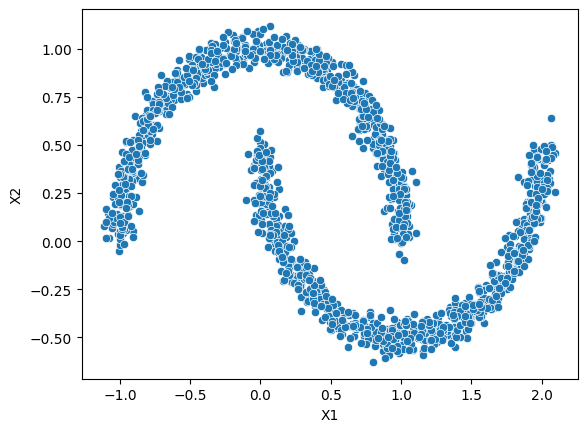

In [11]:
sns.scatterplot(data=moons, x='X1', y='X2')

In [12]:
circles = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\cluster_circles.csv")

In [14]:
circles.shape

(1500, 2)

In [13]:
circles.head()

,X1,X2
0,-0.348677,0.010157
1,-0.176587,-0.954283
2,0.301703,-0.113045
3,-0.782889,-0.719468
4,-0.733280,-0.757354


<Axes: xlabel='X1', ylabel='X2'>

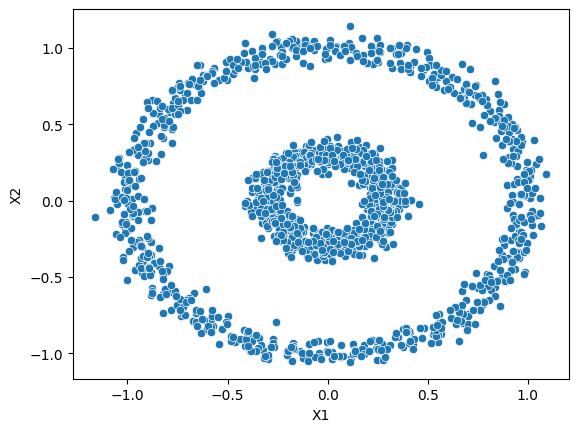

In [15]:
sns.scatterplot(data=circles, x='X1', y='X2')

In [16]:
#K-Menas vs DBSCAN
def display_categories(model, data):
    labels = model.fit_predict(data)
    sns.scatterplot(data=data, x='X1', y='X2', hue=labels, palette='Set1')

In [17]:
from sklearn.cluster import KMeans

In [18]:
model = KMeans(n_clusters=3) # 3 cluster for blobs data

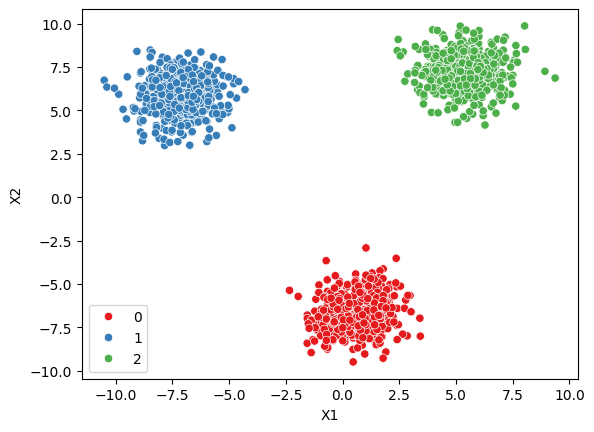

In [19]:
display_categories(model, blobs)

In [24]:
model_moons = KMeans(n_clusters=2) # moons data

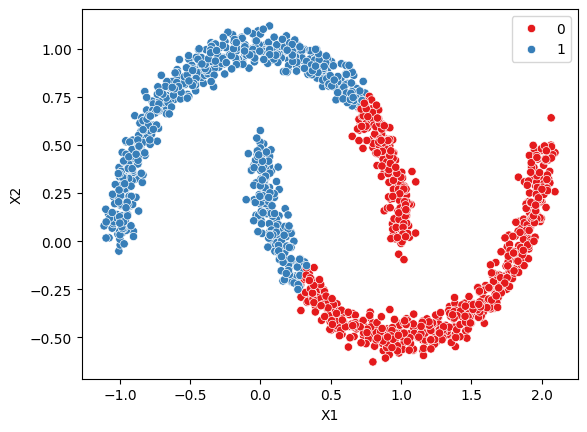

In [25]:
display_categories(model_moons, moons)

In [26]:
model_moons.cluster_centers_

array([[ 1.20634392, -0.07402291],
       [-0.19810638,  0.57233752]])

In [29]:
model_circles = KMeans(n_clusters=2)

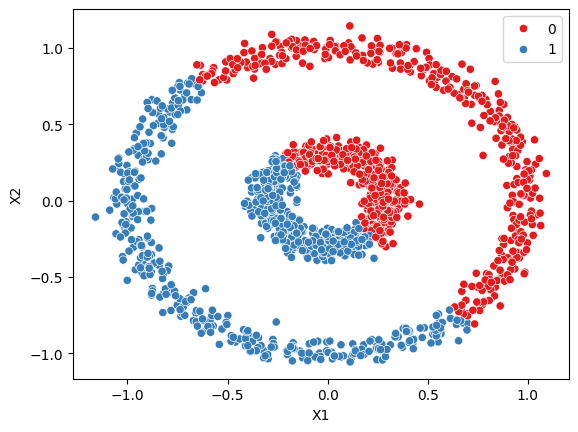

In [30]:
#circles
display_categories(model_circles, circles)

In [31]:
model_circles.cluster_centers_

array([[ 0.3248434 ,  0.28096119],
       [-0.30650534, -0.2569227 ]])

In [32]:
from sklearn.cluster import DBSCAN

In [33]:
# eps, min_samples

In [34]:
dbscan = DBSCAN()

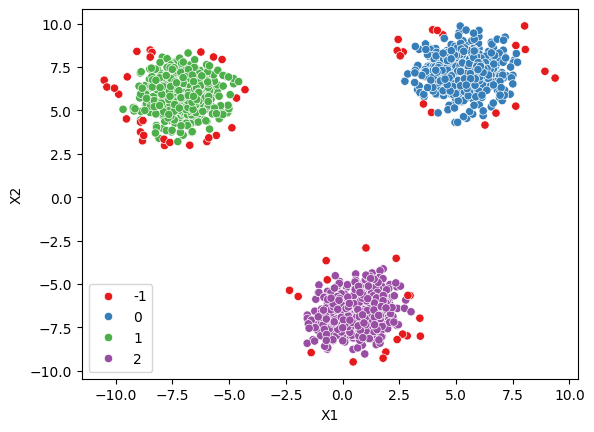

In [35]:
display_categories(dbscan, blobs)

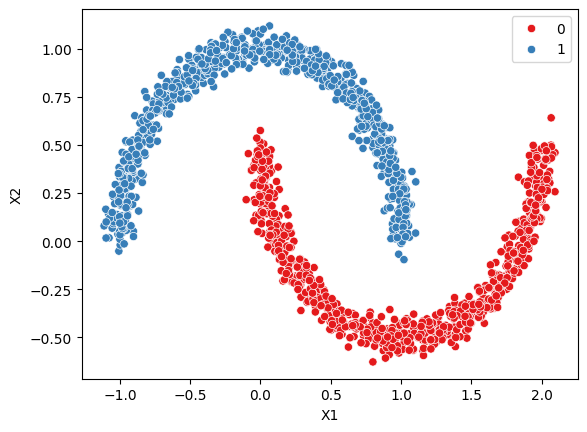

In [37]:
dbscan_moons = DBSCAN(eps=0.15)
display_categories(dbscan_moons, moons)

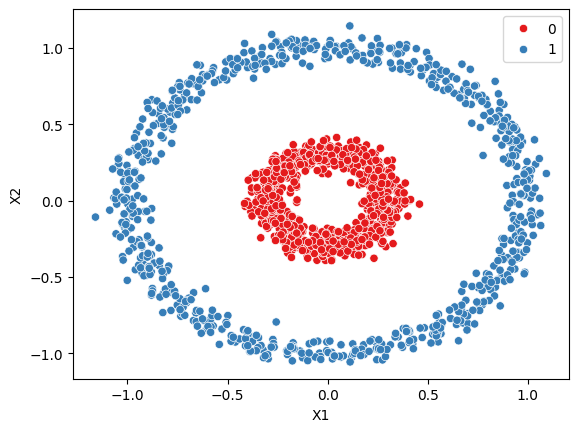

In [38]:
dbscan_circles = DBSCAN(eps=0.15)
display_categories(dbscan_circles, circles)

## **DBSCAN: ключевые гиперпараметры**

 - Эпсилон - Расстояние(окрестность) вокруг точки
 - Минимальное количество точек - минимальное кол-во точек в эпсилон-окрестности точки, чтобы считать ее за *core*-точку

Меняя эти гиперпараметры, мы определяем:
- сколько кластеров будет создано
- сколько точек будут засчитаны как outliers

**Эпсилон**

Увеличивая эпсилон, мы позволяем бОльшему количеству точек стать core точками. В итоге мы так же получаем больше border-точек и меньше outliers, ведь с помощью большей окружности м сможем дальше дотянуться от одной точки к другой.

- Если эпсилон огромный, то все точки будут в окрестности друг друга и попадут в один кластер.
- Если эпсилон крайне маленький, то мы не сможем дотянуться до соседних точек. Уменьшая эпсилон, мы получим, что меньше точек находятся "близко" друг к другу, и мы получаем больше уникальных кластеров. 

**Минимальное количество точек**

Количество точек, входящих в эпсилон-окрестность, чтобы засчитать точку как core (!!включая саму точку!!)

- Увеличивая количество точек, которое требуется для обозначения core-точки, мы получаем большее количество точек-выбросов (Outliers) (при относительно небольшом эпсилон). Если минимальное количество точек очень близко к общему количеству точек, то скорее всего все точки будут выбросами, ведь не будет ни core, ни borders, ведь в окрестности почти всех точек не наберется минимальное кол-во точек, если оно слишком большое.

Как найти оптимальное значение эпсилон и минимального количество точек:

*Метод локтя*: запустить DBSCAN с различными значениями каждого гиперпараметра и сравнить:

    - количество кластеров
    - количество точек-выбросов (Outliers)
    - процент точек-выбросов (Outliers)

Очень сильно зависит от конкретных данных и предметной области. Нужны знания и интуиция о количестве кластеров и допустимом проценте точек-выбросов (Outliers)


## **DBSCAN: поиск гиперпараметров**

In [39]:
two_blobs = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\cluster_two_blobs.csv")

In [41]:
two_blobs_outliers = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\cluster_two_blobs_outliers.csv")

In [40]:
two_blobs.shape

(1000, 2)

In [43]:
two_blobs.head()

,X1,X2
0,0.046733,1.765120
1,-8.994134,-6.508186
2,0.650539,1.264533
3,-9.501554,-6.736493
4,0.057050,0.188215


In [42]:
two_blobs_outliers.shape

(1003, 2)

In [44]:
two_blobs_outliers.head()

,X1,X2
0,0.046733,1.765120
1,-8.994134,-6.508186
2,0.650539,1.264533
3,-9.501554,-6.736493
4,0.057050,0.188215


<Axes: xlabel='X1', ylabel='X2'>

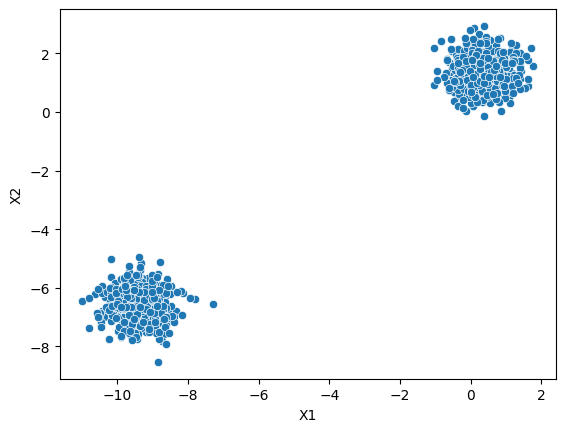

In [45]:
sns.scatterplot(data=two_blobs, x='X1', y='X2')

<Axes: xlabel='X1', ylabel='X2'>

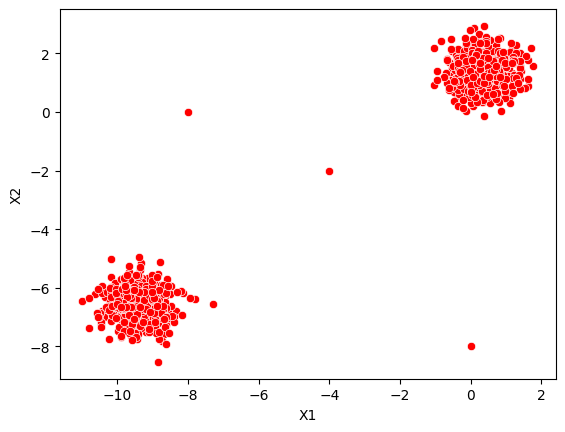

In [47]:
sns.scatterplot(data=two_blobs_outliers, x='X1', y='X2', c='red')

In [55]:
def display_categories(model, data):
    labels = model.fit_predict(data)
    sns.scatterplot(data=data, x='X1', y='X2', hue=labels, palette='Set1')

In [56]:
dbscan = DBSCAN()

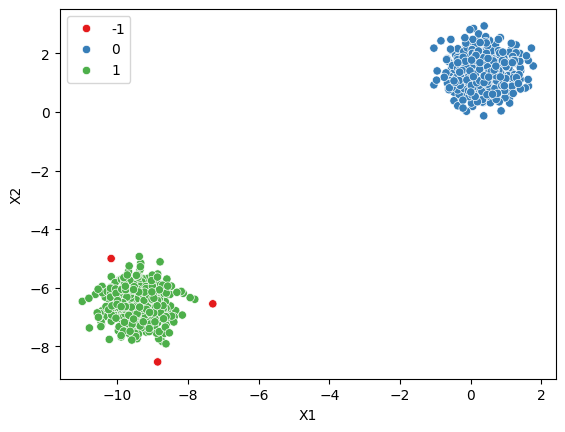

In [57]:
display_categories(dbscan, two_blobs)

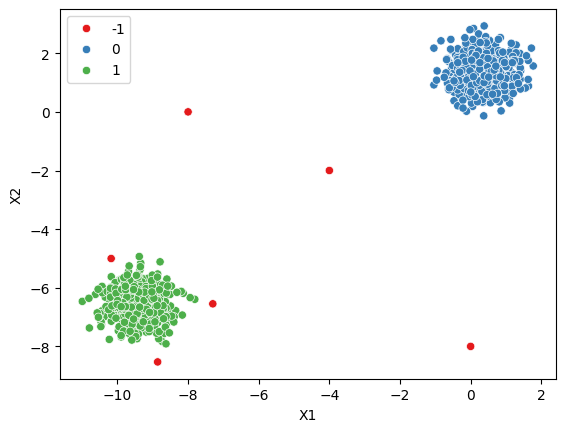

In [58]:
display_categories(dbscan, two_blobs_outliers)

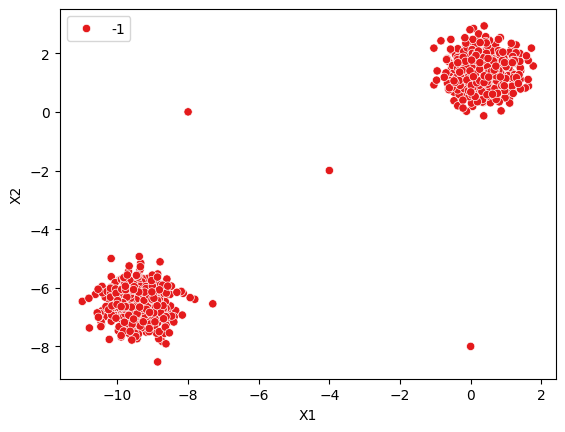

In [59]:
dbscan_001 = DBSCAN(eps=0.01)
display_categories(dbscan_001, two_blobs_outliers)

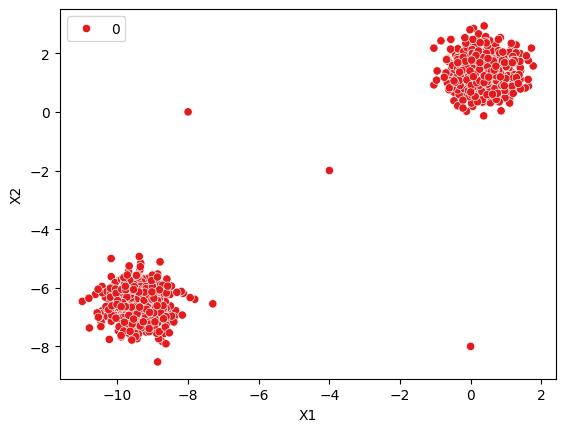

In [61]:
dbscan_10 = DBSCAN(eps=10)
display_categories(dbscan_10, two_blobs_outliers)

Нужна золотая середина!

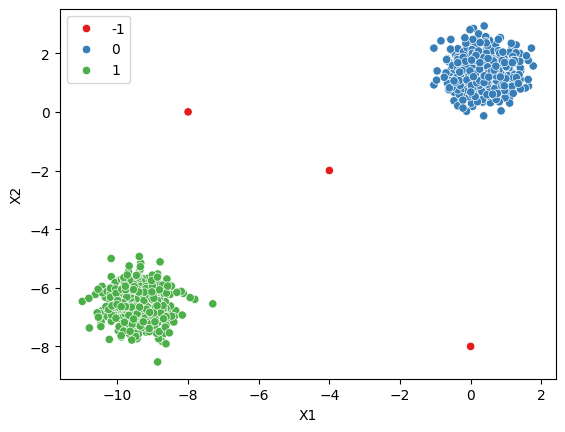

In [62]:
dbscan_1 = DBSCAN(eps=1)
display_categories(dbscan_1, two_blobs_outliers)

In [64]:
dbscan_1.labels_ == -1

array([False, False, False, ...,  True,  True,  True], shape=(1003,))

In [68]:
100 * np.sum(dbscan_1.labels_ == -1) / len(dbscan_1.labels_)

np.float64(0.29910269192422734)

Цикл для различных эпсилон, чтобы найти зависимость количества выбросов от эпсилон

In [82]:
outlier_percent = []
number_of_outliers = []

In [83]:
for eps in np.linspace(start=0.001, stop=7, num=200): # было 7, 100. linspace для нецелых чисел
    dbscan = DBSCAN(eps=eps)
    dbscan.fit(two_blobs_outliers) #нам НЕ НУЖНЫ предсказания, только метки классов
    number_of_outliers.append(np.sum(dbscan.labels_ == -1))
    outlier_percent.append(100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_))
    

нужное нам кол-во выбросов достигается при эпсилон примерно 0.75

(0.0, 10.0)

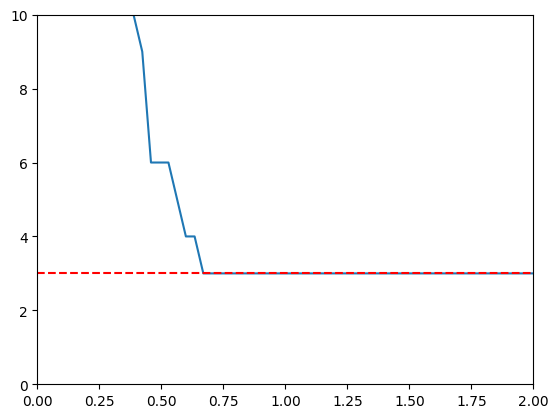

In [101]:
sns.lineplot(x=np.linspace(start=0.001, stop=7, num=200), y=number_of_outliers) #marker='o'
plt.xlim(0,2)
plt.axhline(3, ls='--', c='red')
#plt.hlines(y=200, xmin=0, xmax=2, ls='-.', color='green')
plt.ylim(0,10)

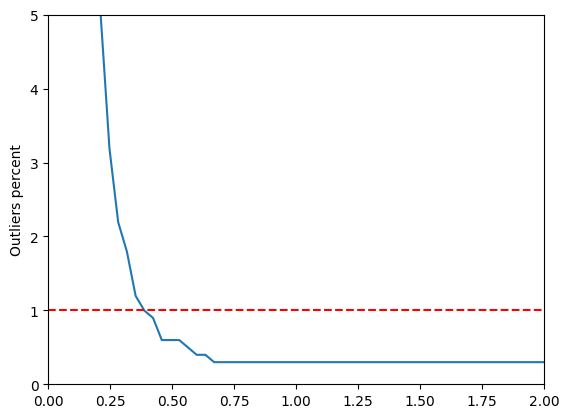

In [103]:
sns.lineplot(x=np.linspace(start=0.001, stop=7, num=200), y=outlier_percent) #marker='o'
plt.xlim(0,2)
plt.ylim(0, 5)
plt.ylabel('Outliers percent')
plt.axhline(1, ls='--', c='red')

Цикл для минимального количества точек

In [104]:
outlier_percent = []
number_of_outliers = []

In [105]:
for n in np.arange(1, 100):
    dbscan = DBSCAN(min_samples=n)
    dbscan.fit(two_blobs_outliers) #нам НЕ НУЖНЫ предсказания, только метки классов
    number_of_outliers.append(np.sum(dbscan.labels_ == -1))
    outlier_percent.append(100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_))
    

(0.0, 100.0)

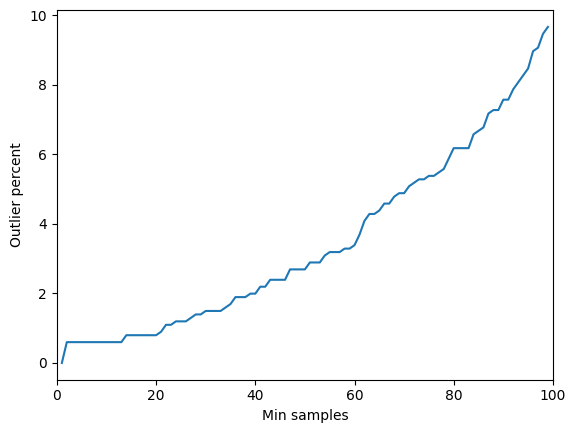

In [107]:
sns.lineplot(x=np.arange(1, 100), y=outlier_percent)
plt.xlabel('Min samples')
plt.ylabel('Outlier percent')
plt.xlim(0, 100)

Хорошее начальное значение для *min_samples* = **2 x number_of_dimensions**

number_of_dimensions = two_blobs.outliers.shape[1] - количество КОЛОНОК

min_samples=1: единичные точки теперь не выбросы, а отдельные калстеры, ведь сама точка ВХОДИТ в min_samples. Мы не получим выбросов!

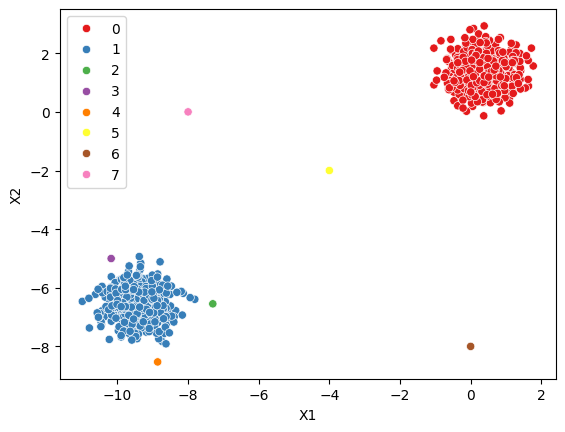

In [110]:
dbscan = DBSCAN(min_samples=1)
display_categories(dbscan, two_blobs_outliers)

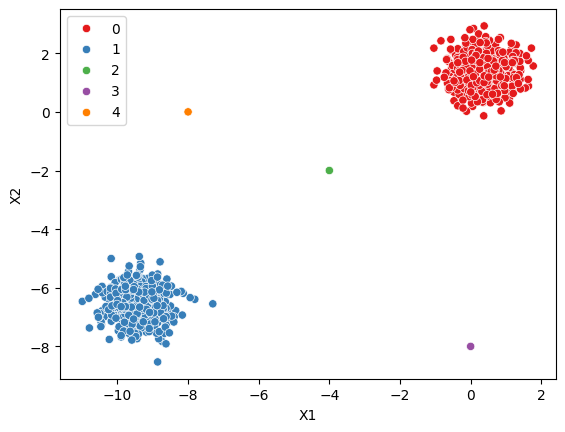

In [109]:
dbscan = DBSCAN(eps=0.75, min_samples=1)
display_categories(dbscan, two_blobs_outliers)